In [84]:
# ## 1) Load Dataset
import pandas as pd

csv_path = '../data/kbopitchingdata.csv'
df = pd.read_csv(csv_path)

print(f'Loaded dataset from: {csv_path}')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')

Loaded dataset from: ../data/kbopitchingdata.csv
Shape: 323 rows x 34 columns


In [85]:
# ## 2) Shape, Columns, and Data Types
print('# Dataset Overview')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')

print('\n## Columns')
for col in df.columns:
    print(f'- {col}')

print('\n## Data Types')
for col, dtype in df.dtypes.items():
    print(f'- {col}: {dtype}')

# Dataset Overview
Shape: 323 rows x 34 columns

## Columns
- id
- year
- team
- average_age
- runs_per_game
- wins
- losses
- win_loss_percentage
- ERA
- run_average_9
- games
- games_started
- games_finished
- complete_game
- shutouts
- saves
- innings_pitched
- hits
- runs
- earned_runs
- home_runs
- walks
- intentional_walks
- strikeouts
- hit_batter
- balks
- wild_pitches
- batters_faced
- WHIP
- hits_9
- homeruns_9
- walks_9
- strikeouts_9
- strikeout_walk

## Data Types
- id: int64
- year: int64
- team: object
- average_age: float64
- runs_per_game: float64
- wins: int64
- losses: int64
- win_loss_percentage: float64
- ERA: float64
- run_average_9: float64
- games: int64
- games_started: float64
- games_finished: float64
- complete_game: int64
- shutouts: int64
- saves: int64
- innings_pitched: float64
- hits: int64
- runs: int64
- earned_runs: int64
- home_runs: int64
- walks: int64
- intentional_walks: float64
- strikeouts: int64
- hit_batter: int64
- balks: float64
- wild_pit

In [86]:
# ## 3) First 10 Rows
print('## First 10 Rows')
print(df.head(10).to_string(index=False))

## First 10 Rows
 id  year          team  average_age  runs_per_game  wins  losses  win_loss_percentage  ERA  run_average_9  games  games_started  games_finished  complete_game  shutouts  saves  innings_pitched  hits  runs  earned_runs  home_runs  walks  intentional_walks  strikeouts  hit_batter  balks  wild_pitches  batters_faced  WHIP  hits_9  homeruns_9  walks_9  strikeouts_9  strikeout_walk
  1  2021      LG Twins         26.3           3.90    72      57                0.558 3.57           3.96    143          143.0           143.0              0        18     32           1264.1  1117   557          501         79    542               17.0        1062          97    5.0          43.0           5416 1.312     8.0         0.6      3.9           7.6            1.96
  2  2021        KT Wiz         28.4           4.06    75      59                0.560 3.67           4.17    143          143.0           141.0              2         6     33           1255.0  1166   581          512   

In [87]:
# ## 4) Summary Statistics
print('## Summary Statistics (Numerical)')
print(df.describe(include=['number']).to_string())

## Summary Statistics (Numerical)
               id         year  average_age  runs_per_game        wins      losses  win_loss_percentage         ERA  run_average_9       games  games_started  games_finished  complete_game    shutouts       saves  innings_pitched         hits        runs  earned_runs   home_runs       walks  intentional_walks   strikeouts  hit_batter       balks  wild_pitches  batters_faced        WHIP      hits_9  homeruns_9     walks_9  strikeouts_9  strikeout_walk
count  323.000000   323.000000   323.000000     323.000000  323.000000  323.000000           323.000000  323.000000     323.000000  323.000000     184.000000      184.000000     323.000000  323.000000  323.000000       323.000000   323.000000  323.000000   323.000000  323.000000  323.000000         184.000000   323.000000  323.000000  184.000000    184.000000     323.000000  323.000000  323.000000  323.000000  323.000000    323.000000      323.000000
mean   162.000000  2002.944272    26.886687       4.6218

In [88]:
# ## 5) Missing Values (Count + %)
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct': missing_pct
})

print('## Missing Values (Count + %)')
print(missing_summary.to_string())

## Missing Values (Count + %)
                     missing_count  missing_pct
id                               0         0.00
year                             0         0.00
team                             0         0.00
average_age                      0         0.00
runs_per_game                    0         0.00
wins                             0         0.00
losses                           0         0.00
win_loss_percentage              0         0.00
ERA                              0         0.00
run_average_9                    0         0.00
games                            0         0.00
games_started                  139        43.03
games_finished                 139        43.03
complete_game                    0         0.00
shutouts                         0         0.00
saves                            0         0.00
innings_pitched                  0         0.00
hits                             0         0.00
runs                             0         0.00
earned_run

In [89]:
# ## 6) Categorical vs Numerical Columns
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

print('## Column Type Classification')
print(f'Categorical ({len(categorical_cols)}): {categorical_cols}')
print(f'Numerical ({len(numerical_cols)}): {numerical_cols}')

## Column Type Classification
Categorical (1): ['team']
Numerical (33): ['id', 'year', 'average_age', 'runs_per_game', 'wins', 'losses', 'win_loss_percentage', 'ERA', 'run_average_9', 'games', 'games_started', 'games_finished', 'complete_game', 'shutouts', 'saves', 'innings_pitched', 'hits', 'runs', 'earned_runs', 'home_runs', 'walks', 'intentional_walks', 'strikeouts', 'hit_batter', 'balks', 'wild_pitches', 'batters_faced', 'WHIP', 'hits_9', 'homeruns_9', 'walks_9', 'strikeouts_9', 'strikeout_walk']


In [90]:
# ## 7) Cleaning Setup (Before Shape)
df_clean = df.copy()
shape_before = df_clean.shape

print('## Before Cleaning Shape')
print(f'{shape_before[0]} rows x {shape_before[1]} columns')

## Before Cleaning Shape
323 rows x 34 columns


In [91]:
# ## 8) Clean Dataset (Names, Types, Duplicates, Missing Values)
# Standardize column names
import re

def standardize_col(col_name: str) -> str:
    col_name = col_name.strip().lower()
    col_name = re.sub(r'[^a-z0-9]+', '_', col_name)
    return col_name.strip('_')

df_clean.columns = [standardize_col(c) for c in df_clean.columns]

# Convert numeric-like strings to numeric where possible
for col in df_clean.columns:
    if df_clean[col].dtype == 'object' and col != 'team':
        converted = pd.to_numeric(df_clean[col], errors='coerce')
        if converted.notna().sum() > 0:
            df_clean[col] = converted

# Remove duplicates
df_clean = df_clean.drop_duplicates()

# Handle missing values logically
# 1) Stats unavailable for many seasons: drop high-missing structural columns
df_clean = df_clean.drop(columns=['games_started', 'games_finished'], errors='ignore')

# 2) Event count columns: missing likely means not recorded -> fill with 0
for c in ['intentional_walks', 'balks', 'wild_pitches']:
    if c in df_clean.columns:
        df_clean[c] = df_clean[c].fillna(0)

# Keep team as categorical/text
if 'team' in df_clean.columns:
    df_clean['team'] = df_clean['team'].astype('string')

shape_after = df_clean.shape

print('## After Cleaning Shape')
print(f'{shape_after[0]} rows x {shape_after[1]} columns')
print('\n## Shape Change')
print(f'Before: {shape_before[0]} x {shape_before[1]}')
print(f'After : {shape_after[0]} x {shape_after[1]}')

## After Cleaning Shape
323 rows x 32 columns

## Shape Change
Before: 323 x 34
After : 323 x 32


In [92]:
# ## 9) Clean DataFrame Output
print('## Clean DataFrame Preview')
print(df_clean.head(10).to_string(index=False))

df_clean

## Clean DataFrame Preview
 id  year          team  average_age  runs_per_game  wins  losses  win_loss_percentage  era  run_average_9  games  complete_game  shutouts  saves  innings_pitched  hits  runs  earned_runs  home_runs  walks  intentional_walks  strikeouts  hit_batter  balks  wild_pitches  batters_faced  whip  hits_9  homeruns_9  walks_9  strikeouts_9  strikeout_walk
  1  2021      LG Twins         26.3           3.90    72      57                0.558 3.57           3.96    143              0        18     32           1264.1  1117   557          501         79    542               17.0        1062          97    5.0          43.0           5416 1.312     8.0         0.6      3.9           7.6            1.96
  2  2021        KT Wiz         28.4           4.06    75      59                0.560 3.67           4.17    143              2         6     33           1255.0  1166   581          512         85    486               18.0        1051          42    1.0          56.0    

,id,year,team,average_age,runs_per_game,wins,losses,win_loss_percentage,era,run_average_9,...,hit_batter,balks,wild_pitches,batters_faced,whip,hits_9,homeruns_9,walks_9,strikeouts_9,strikeout_walk
0,1,2021,LG Twins,26.3,3.90,72,57,0.558,3.57,3.96,...,97,5.0,43.0,5416,1.312,8.0,0.6,3.9,7.6,1.96
1,2,2021,KT Wiz,28.4,4.06,75,59,0.560,3.67,4.17,...,42,1.0,56.0,5359,1.316,8.4,0.6,3.5,7.5,2.16
2,3,2021,Doosan Bears,27.5,4.57,70,65,0.519,4.28,4.66,...,73,7.0,51.0,5596,1.487,9.2,0.7,4.2,7.4,1.77
3,4,2021,Samsung Lions,28.8,4.57,75,59,0.560,4.29,4.70,...,51,3.0,56.0,5496,1.450,9.3,0.9,3.8,7.4,1.96
4,5,2021,NC Dinos,27.7,4.80,67,67,0.500,4.50,4.95,...,77,8.0,74.0,5575,1.476,9.1,0.9,4.2,7.5,1.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318,319,1982,OB Bears,26.5,3.98,56,24,0.700,3.19,3.95,...,33,0.0,0.0,3020,1.260,7.8,0.5,3.6,3.9,1.10
319,320,1982,MBC Blue Dragons,25.9,4.38,46,33,0.582,3.51,4.45,...,47,0.0,0.0,2994,1.298,8.4,0.7,3.3,5.0,1.52
320,321,1982,Lotte Giants,26.3,4.81,31,49,0.388,3.95,4.86,...,29,0.0,0.0,3080,1.435,9.6,0.9,3.3,4.6,1.39
321,322,1982,Haitai Tigers,23.5,4.85,38,42,0.475,3.76,4.93,...,39,0.0,0.0,3067,1.403,8.9,0.6,3.8,4.4,1.18


In [93]:
# ## 10) Feature Engineering for Pitching
# Avoid divide-by-zero by replacing 0 innings/walks with NA in denominators
innings_denom = df_clean['innings_pitched'].replace(0, pd.NA)
walks_denom = df_clean['walks'].replace(0, pd.NA)

df_clean['strikeout_rate'] = df_clean['strikeouts'] / innings_denom
df_clean['walk_rate'] = df_clean['walks'] / innings_denom
df_clean['k_bb_ratio'] = df_clean['strikeouts'] / walks_denom

# Efficiency only if pitches column exists
if 'pitches' in df_clean.columns:
    pitches_denom = df_clean['pitches'].replace(0, pd.NA)
    df_clean['efficiency'] = df_clean['innings_pitched'] / pitches_denom
else:
    df_clean['efficiency'] = pd.NA
    print("'pitches' column not found. 'efficiency' set to NA.")

print('## New Feature Columns Added')
print(['strikeout_rate', 'walk_rate', 'k_bb_ratio', 'efficiency'])

'pitches' column not found. 'efficiency' set to NA.
## New Feature Columns Added
['strikeout_rate', 'walk_rate', 'k_bb_ratio', 'efficiency']


In [94]:
# ## 11) Sample Rows with New Features
sample_cols = [
    'team', 'year', 'innings_pitched', 'strikeouts', 'walks',
    'strikeout_rate', 'walk_rate', 'k_bb_ratio', 'efficiency'
]

available_cols = [c for c in sample_cols if c in df_clean.columns]

print('## Sample Rows with New Features')
print(df_clean[available_cols].head(10).to_string(index=False))

## Sample Rows with New Features
         team  year  innings_pitched  strikeouts  walks  strikeout_rate  walk_rate  k_bb_ratio efficiency
     LG Twins  2021           1264.1        1062    542        0.840123   0.428764    1.959410       <NA>
       KT Wiz  2021           1255.0        1051    486        0.837450   0.387251    2.162551       <NA>
 Doosan Bears  2021           1260.1        1037    586        0.822951   0.465042    1.769625       <NA>
Samsung Lions  2021           1250.0        1031    526        0.824800   0.420800    1.960076       <NA>
     NC Dinos  2021           1247.2        1046    585        0.838679   0.469051    1.788034       <NA>
Kiwoom Heroes  2021           1254.1         893    566        0.712064   0.451320    1.577739       <NA>
  SSG Landers  2021           1267.2        1006    623        0.793876   0.491635    1.614767       <NA>
Hanwha Eagles  2021           1249.2        1006    669        0.805315   0.535543    1.503737       <NA>
   Kia Tigers

In [95]:
# ## 12) Visualization Setup
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

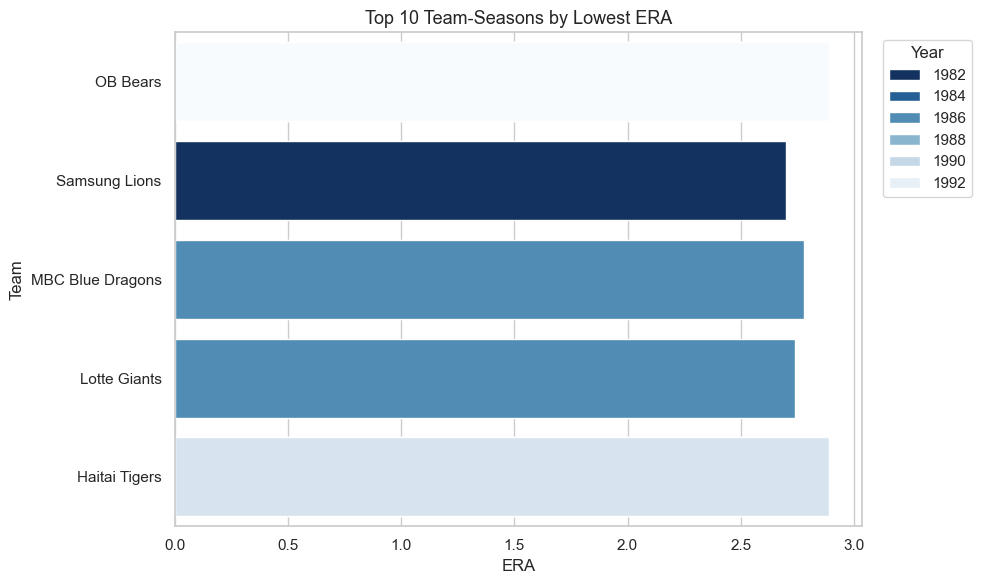

,team,year,era,whip,strikeout_rate,walk_rate,k_bb_ratio
305,OB Bears,1984,2.54,1.187,0.502768,0.373969,1.344411
292,OB Bears,1986,2.61,1.240,0.404020,0.399918,1.010256
317,Samsung Lions,1982,2.70,1.143,0.433177,0.265587,1.631016
311,MBC Blue Dragons,1983,2.72,1.194,0.404096,0.328122,1.231544
293,Lotte Giants,1986,2.74,1.241,0.528885,0.330553,1.600000
294,MBC Blue Dragons,1986,2.78,1.240,0.421534,0.346369,1.217009
296,Haitai Tigers,1986,2.86,1.212,0.542328,0.339845,1.595808
278,Haitai Tigers,1988,2.86,1.183,0.517455,0.306755,1.686869
240,OB Bears,1993,2.89,1.183,0.606275,0.342138,1.772021
256,Haitai Tigers,1991,2.89,1.106,0.687489,0.287560,2.390769


In [96]:
# ## 13) Top 10 Teams/Seasons by Lowest ERA
top_10_era = (
    df_clean.sort_values('era', ascending=True)
    .loc[:, ['team', 'year', 'era', 'whip', 'strikeout_rate', 'walk_rate', 'k_bb_ratio']]
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_era, x='era', y='team', hue='year', dodge=False, palette='Blues_r')
plt.title('Top 10 Team-Seasons by Lowest ERA', fontsize=13)
plt.xlabel('ERA')
plt.ylabel('Team')
plt.legend(title='Year', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

top_10_era

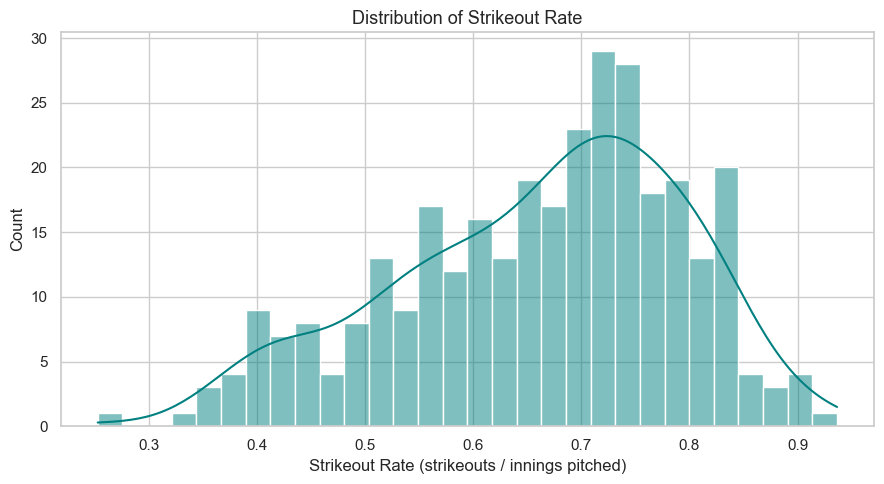

In [97]:
# ## 14) Distribution of Strikeout Rate
plt.figure(figsize=(9, 5))
sns.histplot(df_clean['strikeout_rate'].dropna(), bins=30, kde=True, color='teal')
plt.title('Distribution of Strikeout Rate', fontsize=13)
plt.xlabel('Strikeout Rate (strikeouts / innings pitched)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

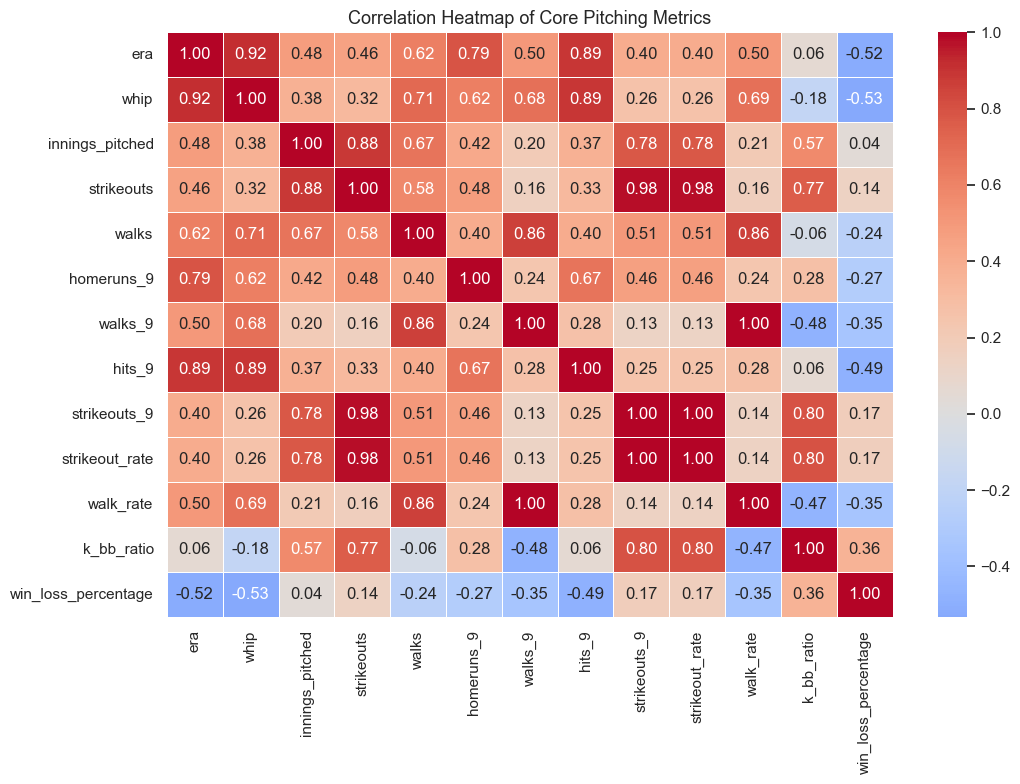

In [98]:
###15) Correlation Heatmap
corr_cols = [
    'era', 'whip', 'innings_pitched', 'strikeouts', 'walks',
    'homeruns_9', 'walks_9', 'hits_9', 'strikeouts_9',
    'strikeout_rate', 'walk_rate', 'k_bb_ratio', 'win_loss_percentage'
]

corr_cols_available = [c for c in corr_cols if c in df_clean.columns]
corr_matrix = df_clean[corr_cols_available].corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Core Pitching Metrics', fontsize=13)
plt.tight_layout()
plt.show()

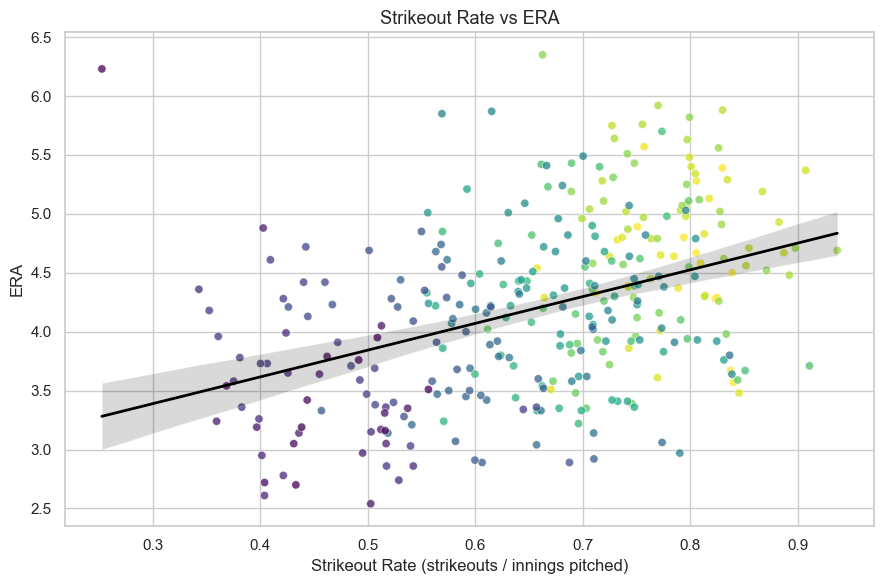

In [99]:
# ## 16) Scatter Plot: Strikeout Rate vs ERA
plot_df = df_clean[['strikeout_rate', 'era', 'team', 'year']].dropna()

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=plot_df,
    x='strikeout_rate',
    y='era',
    hue='year',
    alpha=0.75,
    palette='viridis',
    legend=False
)
sns.regplot(
    data=plot_df,
    x='strikeout_rate',
    y='era',
    scatter=False,
    color='black',
    line_kws={'linewidth': 2}
)
plt.title('Strikeout Rate vs ERA', fontsize=13)
plt.xlabel('Strikeout Rate (strikeouts / innings pitched)')
plt.ylabel('ERA')
plt.tight_layout()
plt.show()

In [100]:
# ## 17) KMeans Clustering Setup (k = 2 to 4)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

cluster_features = [
    'era', 'whip', 'strikeout_rate', 'walk_rate', 'k_bb_ratio',
    'homeruns_9', 'hits_9', 'innings_pitched'
]

cluster_features = [c for c in cluster_features if c in df_clean.columns]
cluster_df = df_clean[cluster_features].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

silhouette_results = []
models = {}
for k in [2, 3, 4]:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_results.append({'k': k, 'silhouette_score': score})
    models[k] = model

silhouette_df = pd.DataFrame(silhouette_results).sort_values('silhouette_score', ascending=False)
best_k = int(silhouette_df.iloc[0]['k'])

print('## Silhouette Scores (Higher is Better)')
print(silhouette_df.to_string(index=False))
print(f'\nSelected k: {best_k}')

## Silhouette Scores (Higher is Better)
 k  silhouette_score
 2          0.304052
 3          0.262933
 4          0.249272

Selected k: 2


In [101]:
# ## 18) Fit Best KMeans and Define Archetypes
best_model = models[best_k]
cluster_df['cluster'] = best_model.predict(X_scaled)

# Join identifiers for readability
id_cols = [c for c in ['team', 'year'] if c in df_clean.columns]
cluster_labeled = cluster_df.join(df_clean.loc[cluster_df.index, id_cols])

# Cluster averages (core comparison)
summary_cols = [
    'era', 'whip', 'strikeout_rate', 'walk_rate', 'k_bb_ratio',
    'homeruns_9', 'hits_9', 'innings_pitched'
]

cluster_summary = (
    cluster_labeled
    .groupby('cluster')[summary_cols]
    .mean()
    .round(3)
)

cluster_counts = cluster_labeled['cluster'].value_counts().sort_index().rename('count')
cluster_summary = cluster_summary.join(cluster_counts)

# Heuristic archetype labels from cluster tendencies
archetype_map = {}
for cluster_id, row in cluster_summary.iterrows():
    if row['strikeout_rate'] >= cluster_summary['strikeout_rate'].median() and row['walk_rate'] <= cluster_summary['walk_rate'].median():
        label = 'Power-Control'
    elif row['strikeout_rate'] >= cluster_summary['strikeout_rate'].median():
        label = 'Power'
    elif row['walk_rate'] <= cluster_summary['walk_rate'].median() and row['era'] <= cluster_summary['era'].median():
        label = 'Control-Run Prevention'
    else:
        label = 'Contact/High Traffic'
    archetype_map[cluster_id] = label

cluster_labeled['archetype'] = cluster_labeled['cluster'].map(archetype_map)
cluster_summary['archetype'] = cluster_summary.index.map(archetype_map)

print('## Cluster Archetypes')
print(pd.Series(archetype_map, name='archetype').to_string())

## Cluster Archetypes
0    Control-Run Prevention
1                     Power


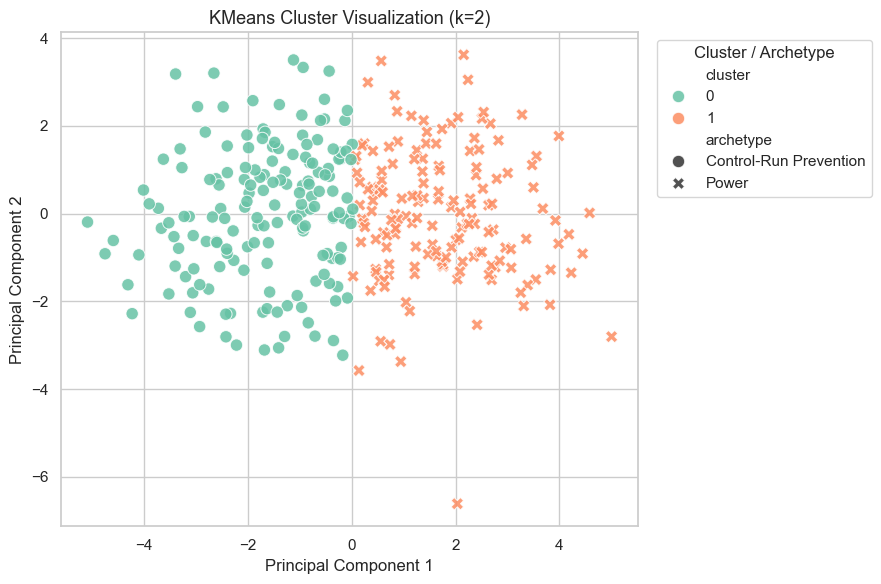

In [102]:
# ## 19) Cluster Visualization (PCA 2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plot_clusters = cluster_labeled.copy()
plot_clusters['pc1'] = X_pca[:, 0]
plot_clusters['pc2'] = X_pca[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=plot_clusters,
    x='pc1',
    y='pc2',
    hue='cluster',
    style='archetype',
    palette='Set2',
    s=80,
    alpha=0.85
)
plt.title(f'KMeans Cluster Visualization (k={best_k})', fontsize=13)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster / Archetype', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [103]:
# ## 20) Cluster Summary Table (Averages)
cluster_summary_display = cluster_summary.reset_index().sort_values('cluster')

print('## Cluster Summary (Mean Metrics + Count)')
print(cluster_summary_display.to_string(index=False))

cluster_summary_display

## Cluster Summary (Mean Metrics + Count)
 cluster   era  whip  strikeout_rate  walk_rate  k_bb_ratio  homeruns_9  hits_9  innings_pitched  count              archetype
       0 3.644 1.318           0.594      0.369       1.632       0.665   8.544         1077.993    165 Control-Run Prevention
       1 4.797 1.486           0.730      0.419       1.778       1.015   9.607         1198.975    158                  Power


,cluster,era,whip,strikeout_rate,walk_rate,k_bb_ratio,homeruns_9,hits_9,innings_pitched,count,archetype
0,0,3.644,1.318,0.594,0.369,1.632,0.665,8.544,1077.993,165,Control-Run Prevention
1,1,4.797,1.486,0.730,0.419,1.778,1.015,9.607,1198.975,158,Power


In [104]:
# ## 21) Regression Setup: Predict ERA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

feature_candidates = [
    'strikeout_rate', 'walk_rate', 'k_bb_ratio',
    'innings_pitched', 'whip', 'homeruns_9', 'hits_9',
    'walks_9', 'strikeouts_9', 'win_loss_percentage'
]

target_col = 'era'
feature_cols = [c for c in feature_candidates if c in df_clean.columns]

model_df = df_clean[feature_cols + [target_col]].dropna().copy()

X = model_df[feature_cols]
y = model_df[target_col]

print('## Modeling Dataset')
print(f'Features used ({len(feature_cols)}): {feature_cols}')
print(f'Samples: {len(model_df)}')

## Modeling Dataset
Features used (10): ['strikeout_rate', 'walk_rate', 'k_bb_ratio', 'innings_pitched', 'whip', 'homeruns_9', 'hits_9', 'walks_9', 'strikeouts_9', 'win_loss_percentage']
Samples: 323


In [105]:
# ## 22) Train/Test Split and Train Linear Regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print('## Model Performance')
print(f'RMSE: {rmse:.4f}')
print(f'R^2 : {r2:.4f}')

## Model Performance
RMSE: 0.1907
R^2 : 0.9430


In [106]:
# ## 23) Print Coefficients
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lin_reg.coef_
}).sort_values('coefficient', key=lambda s: s.abs(), ascending=False)

print('## Linear Regression Coefficients (sorted by absolute impact)')
print(coef_df.to_string(index=False))

print(f'\nIntercept: {lin_reg.intercept_:.6f}')
coef_df

## Linear Regression Coefficients (sorted by absolute impact)
            feature  coefficient
     strikeout_rate    -4.902209
               whip     4.725695
win_loss_percentage    -1.164972
          walk_rate     1.145052
         homeruns_9     0.814223
       strikeouts_9     0.473462
         k_bb_ratio     0.439135
            walks_9    -0.117342
             hits_9    -0.004831
    innings_pitched     0.000388

Intercept: -3.279422


,feature,coefficient
0,strikeout_rate,-4.902209
4,whip,4.725695
9,win_loss_percentage,-1.164972
1,walk_rate,1.145052
5,homeruns_9,0.814223
8,strikeouts_9,0.473462
2,k_bb_ratio,0.439135
7,walks_9,-0.117342
6,hits_9,-0.004831
3,innings_pitched,0.000388
